In [1]:
# =============================================
# TASK 2: TECHNICAL INDICATORS ANALYSIS
# =============================================

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

plt.style.use('seaborn-v0_8')

# ======================
# 1. Load Stock Price Data
# ======================

# Choose some popular stocks from the dataset
stocks = ['AAPL', 'TSLA', 'AMZN', 'GOOGL', 'MSFT']

print("Downloading stock data...")
data = {}

for stock in stocks:
    data[stock] = yf.download(stock, start="2020-01-01", end="2020-12-31", progress=False)
    print(f"{stock}: {len(data[stock])} days downloaded")

# Example: Use AAPL for detailed analysis
df = data['AAPL'].copy()
print(df.head())

AAPL: 252 days downloaded
TSLA: 252 days downloaded
AMZN: 252 days downloaded
GOOGL: 252 days downloaded
MSFT: 252 days downloaded
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333893  72.394101  71.091199  71.344069  135480400
2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800
2020-01-06  72.201431  72.239965  70.503569  70.754036  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017822  73.318862  71.565606  71.565606  132079200


In [9]:
import yfinance as yf
import pandas as pd
import talib

# Clean download for one stock
df = yf.download('AAPL', 
                 start="2019-01-01", 
                 end="2021-12-31", 
                 progress=False)

# Rename Adj Close to Close (recommended)
df = df.rename(columns={'Adj Close': 'Close'}) # type: ignore

print(" Download Successful!")
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

 Download Successful!
Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

First 5 rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.469204  37.689864  36.593688  36.750285  148158800
2019-01-03  33.736992  34.574544  33.691911  34.161698  365248800
2019-01-04  35.177197  35.246006  34.118988  34.292192  234428400
2019-01-07  35.098915  35.312458  34.617263  35.281612  219111200
2019-01-08  35.767994  36.021871  35.238890  35.485646  164101200


In [13]:
print("Shape of df:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nNaN count in Close:", df['Close'].isna().sum() if 'Close' in df.columns else "No 'Close' column")
print("Total rows with valid Close price:", len(df['Close'].dropna()))

Shape of df: (756, 5)
Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

First 3 rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.469204  37.689864  36.593688  36.750285  148158800
2019-01-03  33.736992  34.574544  33.691911  34.161698  365248800
2019-01-04  35.177197  35.246006  34.118988  34.292192  234428400

NaN count in Close: Ticker
AAPL    0
dtype: int64
Total rows with valid Close price: 756


In [17]:
# ======================
# FIX MULTI-INDEX & CLEAN DATA
# ======================

# Reset to single level columns and select only AAPL
df = df.droplevel(0, axis=1) if isinstance(df.columns, pd.MultiIndex) else df # type: ignore

# If still has MultiIndex, take only AAPL columns
if isinstance(df.columns, pd.MultiIndex): # type: ignore
    df = df['AAPL'] # type: ignore

# Rename columns to standard names
df = df.rename(columns={ # type: ignore
    'Close': 'Close',
    'High': 'High',
    'Low': 'Low',
    'Open': 'Open',
    'Volume': 'Volume'
})

print(" Fixed Columns:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

 Fixed Columns:
['AAPL', 'AAPL', 'AAPL', 'AAPL', 'AAPL']

First 3 rows:
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.469204  37.689864  36.593688  36.750285  148158800
2019-01-03  33.736992  34.574544  33.691911  34.161698  365248800
2019-01-04  35.177197  35.246006  34.118988  34.292192  234428400


In [19]:
# ======================
# STRONG CLEANING FOR MULTI-INDEX
# ======================

# Reset columns completely
df = df.reset_index() # type: ignore

# If there's a 'Date' column, set it as index again
if 'Date' in df.columns:
    df = df.set_index('Date')

# Take only the first level (the price data)
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(0, axis=1)   # Drop the 'Price' level

# Rename columns to standard names
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

print("Final Cleaned Columns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Final Cleaned Columns:
['Close', 'High', 'Low', 'Open', 'Volume']

First 5 rows:
                Close       High        Low       Open     Volume
Date                                                             
2019-01-02  37.469204  37.689864  36.593688  36.750285  148158800
2019-01-03  33.736992  34.574544  33.691911  34.161698  365248800
2019-01-04  35.177197  35.246006  34.118988  34.292192  234428400
2019-01-07  35.098915  35.312458  34.617263  35.281612  219111200
2019-01-08  35.767994  36.021871  35.238890  35.485646  164101200


In [ ]:
import talib

close = df['Close'].values

# Technical Indicators
df['SMA_20'] = talib.SMA(close, timeperiod=20) # type: ignore
df['SMA_50'] = talib.SMA(close, timeperiod=50)
df['EMA_20'] = talib.EMA(close, timeperiod=20)

df['RSI'] = talib.RSI(close, timeperiod=14)

df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = talib.MACD(close)

print("\nSUCCESS! Technical Indicators Calculated")
print(df[['Close', 'SMA_20', 'SMA_50', 'RSI']].tail(10))


SUCCESS! Technical Indicators Calculated
                 Close      SMA_20      SMA_50        RSI
Date                                                     
2021-12-16  168.407761  163.398846  152.206205  59.485647
2021-12-17  167.312790  164.047507  152.754832  57.779173
2021-12-20  165.953903  164.497221  153.283896  55.645713
2021-12-21  169.121460  165.082336  153.878067  59.408219
2021-12-22  171.712173  165.777924  154.549435  62.230271
2021-12-23  172.337860  166.478889  155.245030  62.901098
2021-12-27  176.297302  167.628591  155.964171  66.906703
2021-12-28  175.280548  168.559789  156.641890  64.966864
2021-12-29  175.368530  169.248045  157.287982  65.061263
2021-12-30  174.214935  169.904527  157.867855  62.676551


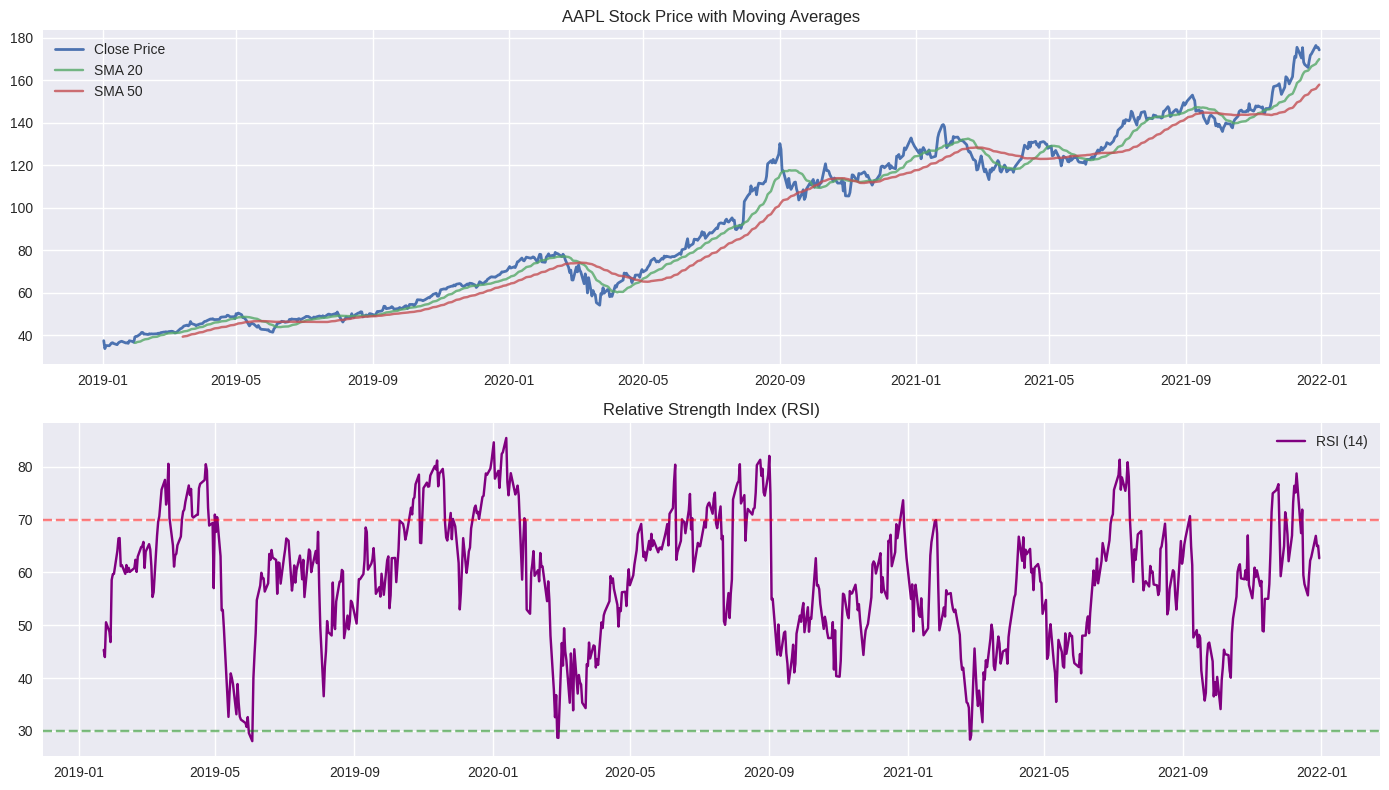

In [21]:
# ======================
# 3. Visualizations
# ======================

# Plot 1: Price + Moving Averages
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
plt.plot(df.index, df['SMA_20'], label='SMA 20', alpha=0.8)
plt.plot(df.index, df['SMA_50'], label='SMA 50', alpha=0.8)
plt.title('AAPL Stock Price with Moving Averages')
plt.legend()
plt.grid(True)

# Plot 2: RSI
plt.subplot(2, 1, 2)
plt.plot(df.index, df['RSI'], label='RSI (14)', color='purple')
plt.axhline(70, color='red', linestyle='--', alpha=0.5)
plt.axhline(30, color='green', linestyle='--', alpha=0.5)
plt.title('Relative Strength Index (RSI)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

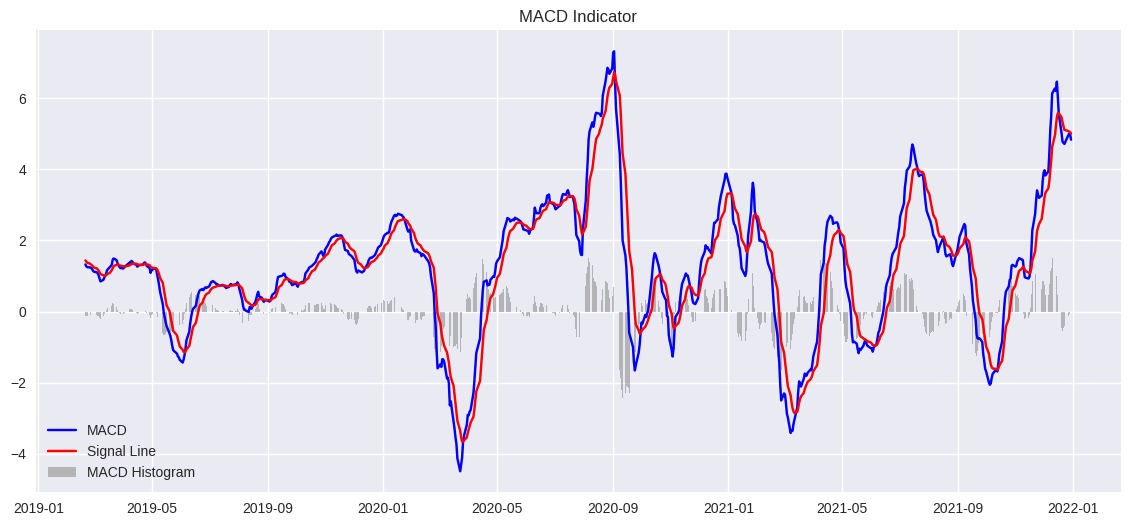

In [22]:
# Plot 3: MACD
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['MACD'], label='MACD', color='blue')
plt.plot(df.index, df['MACD_Signal'], label='Signal Line', color='red')
plt.bar(df.index, df['MACD_Hist'], label='MACD Histogram', color='grey', alpha=0.5)
plt.title('MACD Indicator')
plt.legend()
plt.grid(True)
plt.show()